In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
print("Librerías cargadas ✅")

Librerías cargadas ✅


In [2]:
df = pd.read_csv('../data/creditcard.csv')
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"\nColumnas: {list(df.columns)}")
df.head()

Filas: 284,807 | Columnas: 31

Columnas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(df.info())
print(f"\nValores nulos: {df.isnull().sum().sum()}")
print(f"\nEstadísticas básicas:")
df[['Amount', 'Time']].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Amount,Time
count,284807.000000,284807.000000
mean,88.349619,94813.859575
std,250.120109,47488.145955
min,0.000000,0.000000
25%,5.600000,54201.500000
50%,22.000000,84692.000000
75%,77.165000,139320.500000
max,25691.160000,172792.000000


Transacciones normales: 284,315 (99.827%)
Transacciones fraudulentas: 492 (0.173%)


/var/folders/z3/c6hz7gq52z9f7yk3q3whc8w80000gn/T/ipykernel_42921/1384566012.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette=['#2ecc71','#e74c3c'])


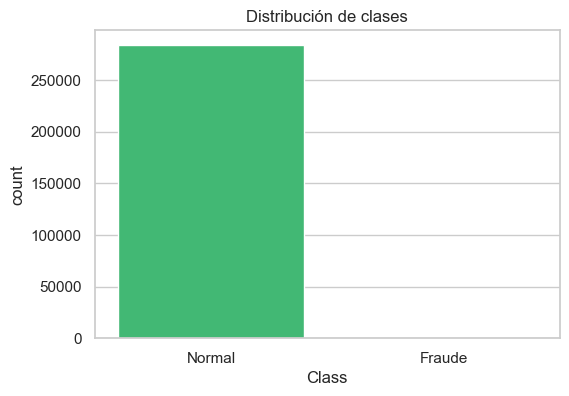

In [4]:
fraude = df['Class'].value_counts()
pct = df['Class'].value_counts(normalize=True) * 100

print(f"Transacciones normales: {fraude[0]:,} ({pct[0]:.3f}%)")
print(f"Transacciones fraudulentas: {fraude[1]:,} ({pct[1]:.3f}%)")

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Class', palette=['#2ecc71','#e74c3c'])
plt.xticks([0,1], ['Normal', 'Fraude'])
plt.title('Distribución de clases')
plt.savefig('../data/clase_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/z3/c6hz7gq52z9f7yk3q3whc8w80000gn/T/ipykernel_42921/2945670093.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='Amount', palette=['#2ecc71','#e74c3c'], ax=axes[1])


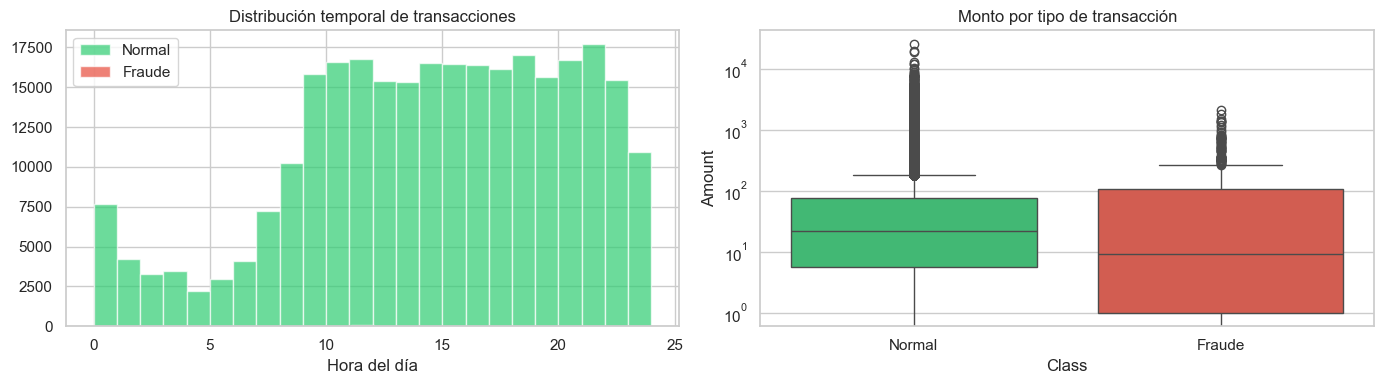

In [5]:
df['Hour'] = (df['Time'] / 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[df['Class']==0]['Hour'], bins=24, color='#2ecc71', alpha=0.7, label='Normal')
axes[0].hist(df[df['Class']==1]['Hour'], bins=24, color='#e74c3c', alpha=0.7, label='Fraude')
axes[0].set_title('Distribución temporal de transacciones')
axes[0].set_xlabel('Hora del día')
axes[0].legend()

sns.boxplot(data=df, x='Class', y='Amount', palette=['#2ecc71','#e74c3c'], ax=axes[1])
axes[1].set_title('Monto por tipo de transacción')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['Normal', 'Fraude'])
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('../data/analisis_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Ordenar por tiempo
df = df.sort_values('Time').reset_index(drop=True)

# Normalizar Amount y Time
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Features para la LSTM (excluimos Class y columnas originales)
feature_cols = [c for c in df.columns if c not in ['Class', 'Time', 'Amount', 'Hour']]

print(f"Features para el modelo: {len(feature_cols)}")
print(f"Columnas: {feature_cols}")

WINDOW_SIZE = 10
print(f"\nCada secuencia tendrá {WINDOW_SIZE} transacciones consecutivas")
print(f"La LSTM aprenderá si el patrón de las últimas {WINDOW_SIZE} transacciones es sospechoso")

Features para el modelo: 30
Columnas: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled']

Cada secuencia tendrá 10 transacciones consecutivas
La LSTM aprenderá si el patrón de las últimas 10 transacciones es sospechoso


In [7]:
print("=== HALLAZGOS DEL EDA ===\n")
print(f"1. Desbalance extremo: solo {pct[1]:.3f}% son fraudes → reto principal del modelo")
print(f"2. Las variables V1-V28 son componentes PCA — ya están anonimizadas por el banco")
print(f"3. Los montos de fraude tienden a ser menores que transacciones normales")
print(f"4. Usaremos ventanas de {WINDOW_SIZE} transacciones para capturar patrones secuenciales")
print(f"\nDataset listo para Semana 2: construcción de la LSTM en PyTorch ✅")

=== HALLAZGOS DEL EDA ===

1. Desbalance extremo: solo 0.173% son fraudes → reto principal del modelo
2. Las variables V1-V28 son componentes PCA — ya están anonimizadas por el banco
3. Los montos de fraude tienden a ser menores que transacciones normales
4. Usaremos ventanas de 10 transacciones para capturar patrones secuenciales

Dataset listo para Semana 2: construcción de la LSTM en PyTorch ✅
